# Depth bands of PSBD-TM

PSBD-TM masks tokens at the attention input of all 12 blocks. `mechanism.ipynb` found that the class token reads a patch trigger in the late blocks, which raises an obvious question: would masking only there do as well, or better, since the early masks only destroy clean evidence? A **band** restricts the same placement to blocks 1 to 4, 5 to 8 or 9 to 12 and this notebook asks whether the detection signal comes from 1 depth of the network or needs the perturbation at every depth. It follows `scripts/paper/tab_depth_bands.py`, which reads each band at the matched rate rule rather than the adaptive one and pairs each band with the all-blocks placement of the same family on the same models. The same comparison is repeated for residual dropout (`pre_residual`), where the answer turns out to differ. It reads cached JSON only and runs in about 30 seconds.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json
import logging
import warnings

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)
# torchvision's ToTensor deprecation fires once per dataset load and says nothing
# about the numbers below.
warnings.filterwarnings("ignore", message="The transform `ToTensor", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from scripts.paper._common import word_list

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline


def macro(table, name):
    """1 value of paper/tables/<table>.macros.json, the string headline.tex prints."""
    with open(f"paper/tables/{table}.macros.json") as handle:
        sidecar = json.load(handle)
    value = sidecar["macros"][name]["value"]
    return value


def show_diagram(name, width=None):
    """Embed a TikZ diagram rendered by notebooks/figures/render.py."""
    display(Image(filename=f"notebooks/figures/{name}.png", width=width))

from cli.compare_detectors import psbd_rate
from defenses.decision import ADAPTIVE_SHIFT_TARGET, HEADLINE_QUANTILE, PLACEMENT_MATCH_TARGET, RECOMMENDED_PLACEMENT
from scripts.paper._common import (
    BOOTSTRAP_RESAMPLES,
    BOOTSTRAP_SEED,
    OKABE_ITO,
    attack_label,
    bootstrap_ci,
    clearing_cells,
    fmt,
    load_coverage,
    load_psbd_metrics,
    macro_name,
)
from scripts.paper._style import TEXT_WIDTH, attack_color, legend_above
from scripts.paper.tab_depth_bands import (
    INPUT_SIDE_1_4,
    INPUT_SIDE_5_8,
    INPUT_SIDE_9_12,
    INPUT_SIDE_ALL,
    RESIDUAL_1_4,
    RESIDUAL_5_8,
    RESIDUAL_9_12,
    RESIDUAL_ALL,
    measure_placement,
)

## Why the matched rule

The adaptive rule picks the smallest rate whose clean-validation predictions shift at the adaptive target (`ADAPTIVE_SHIFT_TARGET`). A band perturbs 4 of the 12 blocks, so on many models no rate on the ladder shifts the predictions that often, and the adaptive rule returns nothing. The matched rule reads every placement at the rate whose clean-validation shift ratio is closest to `PLACEMENT_MATCH_TARGET`, which a band reaches on every model it was swept on, so the comparison rests on the whole swept panel and every band is compared at the same measured disturbance of the clean model. The figure counts, per band, the successful models swept and the models on which each rule found a rate.

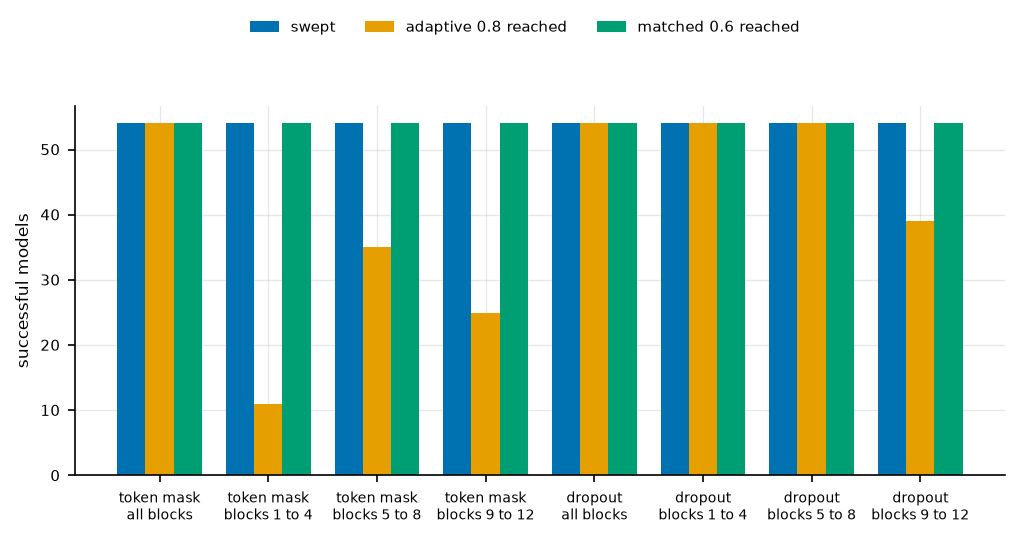

56 successful models, threshold at the 25% clean-validation quantile


swept  adaptive 0.8 reached  \
family                      band                                          
token mask, attention input all blocks         54                    54   
                            blocks 1 to 4      54                    11   
                            blocks 5 to 8      54                    35   
                            blocks 9 to 12     54                    25   
dropout, before both adds   all blocks         54                    54   
                            blocks 1 to 4      54                    54   
                            blocks 5 to 8      54                    54   
                            blocks 9 to 12     54                    39   

                                            matched 0.6 reached  
family                      band                                 
token mask, attention input all blocks                       54  
                            blocks 1 to 4                    54  
                            blocks 5 to 8                    54  
                            blocks 9 to 12                   54  
dropout, before both adds   all blocks                       54  
                            blocks 1 to 4                    54  
                            blocks 5 to 8                    54  
                            blocks 9 to 12                   54

In [2]:
assert INPUT_SIDE_ALL == RECOMMENDED_PLACEMENT
BANDS = {
    "all blocks": INPUT_SIDE_ALL,
    "blocks 1 to 4": INPUT_SIDE_1_4,
    "blocks 5 to 8": INPUT_SIDE_5_8,
    "blocks 9 to 12": INPUT_SIDE_9_12,
}
RESIDUAL_BANDS = {
    "all blocks": RESIDUAL_ALL,
    "blocks 1 to 4": RESIDUAL_1_4,
    "blocks 5 to 8": RESIDUAL_5_8,
    "blocks 9 to 12": RESIDUAL_9_12,
}

cells = clearing_cells(load_coverage("results"))
reports = {cell["folder_name"]: load_psbd_metrics("results", cell["folder_name"]) or {} for cell in cells}
attack_of = {cell["folder_name"]: cell["attack"] for cell in cells}

reach_rows = []
for family, bands in (("token mask, attention input", BANDS), ("dropout, before both adds", RESIDUAL_BANDS)):
    for band, placement in bands.items():
        blocks = [report.get("placements", {}).get(placement) for report in reports.values()]
        swept = [block for block in blocks if block is not None]
        reach_rows.append({
            "family": family, "band": band, "swept": len(swept),
            f"adaptive {ADAPTIVE_SHIFT_TARGET} reached": sum(psbd_rate(b, "adaptive") is not None for b in swept),
            f"matched {PLACEMENT_MATCH_TARGET} reached": sum(psbd_rate(b, "matched") is not None for b in swept),
        })
reach = pd.DataFrame(reach_rows).set_index(["family", "band"])

figure, axis = plt.subplots(figsize=(8.0, 3.2))
positions = np.arange(len(reach))  # (family and band rows,)
for offset, column in enumerate(reach.columns):
    axis.bar(positions + (offset - 1) * 0.26, reach[column], width=0.26, label=column)
axis.set_xticks(positions, labels=[f"{f.split(',')[0]}\n{b}" for f, b in reach.index], fontsize=6.5)
axis.set_ylabel("successful models")
legend_above(figure, [axis], columns=3)
plt.show()
print(f"{len(cells)} successful models, threshold at the {HEADLINE_QUANTILE:.0%} clean-validation quantile")
token_reach = reach.loc["token mask, attention input"]
residual_reach = reach.loc["dropout, before both adds"]
adaptive_column = f"adaptive {ADAPTIVE_SHIFT_TARGET} reached"
matched_column = f"matched {PLACEMENT_MATCH_TARGET} reached"
reach

In [3]:
display(Markdown(rf"""
Every band of both families was swept on {int(token_reach["swept"].min())} of the {len(cells)} successful models, the others being cells still queued. For token masking the adaptive rule finds a rate on {word_list([f"{int(token_reach.loc[b, adaptive_column])} for {b}" for b in list(BANDS)[1:]])}, while the matched rule reaches every band on {int(token_reach[matched_column].min())} models. Masking 4 blocks disturbs the clean model little, because a token hidden in 1 block still delivers its content from the stream in the next, the same fact `mechanism.ipynb` measured for the trigger. The residual bands reach the adaptive target far more often ({word_list([f"{int(residual_reach.loc[b, adaptive_column])} for {b}" for b in list(RESIDUAL_BANDS)[1:]])}), since dropout on the stream is not repaired downstream. At the adaptive rule the band comparison would therefore be taken over different, easier subsets, as `placement-walk.ipynb` showed. The matched rule avoids that.
"""))


Every band of both families was swept on 54 of the 56 successful models, the others being cells still queued. For token masking the adaptive rule finds a rate on 11 for blocks 1 to 4, 35 for blocks 5 to 8 and 25 for blocks 9 to 12, while the matched rule reaches every band on 54 models. Masking 4 blocks disturbs the clean model little, because a token hidden in 1 block still delivers its content from the stream in the next, the same fact `mechanism.ipynb` measured for the trigger. The residual bands reach the adaptive target far more often (54 for blocks 1 to 4, 54 for blocks 5 to 8 and 39 for blocks 9 to 12), since dropout on the stream is not repaired downstream. At the adaptive rule the band comparison would therefore be taken over different, easier subsets, as `placement-walk.ipynb` showed. The matched rule avoids that.


## Paired band readings

For each band the generator pairs it with its family's all-blocks placement on the models carrying both at the matched rule, and reports the mean paired gap with a 95% bootstrap interval over models. The cell recomputes those gaps and checks them against `paper/tables/depth_bands.macros.json`. The bar figure then uses the models carrying all 4 token-mask readings, so every bar averages the same models, with each model as a dot.

In [4]:
def band_frame(bands):
    rows = []
    for folder, report in reports.items():
        row = {"folder": folder, "attack": attack_of[folder]}
        for band, placement in bands.items():
            measured = measure_placement(report, placement)
            row[band] = None if measured is None else measured["auroc"]
        rows.append(row)
    frame = pd.DataFrame(rows).set_index("folder")
    return frame


def paired_gaps(frame, bands, family_macro):
    gap_rows = []
    for band in list(bands)[1:]:
        both = frame[[band, "all blocks"]].dropna()
        deltas = (both[band] - both["all blocks"]).tolist()
        low, high = bootstrap_ci(deltas, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
        stem = macro_name(f"band_{band.split()[1]}_{band.split()[3]}_minus_all_{family_macro}")
        assert macro("depth_bands", stem) == fmt(np.mean(deltas), signed=True), stem
        assert macro("depth_bands", f"{stem}Low") == fmt(low, signed=True), stem
        gap_rows.append({"band": band, "paired n": len(deltas), "mean band AUROC": both[band].mean(), "gap to all blocks": np.mean(deltas), "low": low, "high": high})
    gaps = pd.DataFrame(gap_rows).set_index("band")
    return gaps


token_frame = band_frame(BANDS)
residual_frame = band_frame(RESIDUAL_BANDS)
token_gaps = paired_gaps(token_frame, BANDS, "input_side")
residual_gaps = paired_gaps(residual_frame, RESIDUAL_BANDS, "residual")
print("paired gaps match the BandXMinusAllInputSide and BandXMinusAllResidual macros")
token_gaps.round(3)

paired gaps match the BandXMinusAllInputSide and BandXMinusAllResidual macros


,paired n,mean band AUROC,gap to all blocks,low,high
band,,,,,
blocks 1 to 4,54,0.833,-0.104,-0.138,-0.073
blocks 5 to 8,54,0.867,-0.071,-0.112,-0.034
blocks 9 to 12,54,0.886,-0.052,-0.106,-0.006


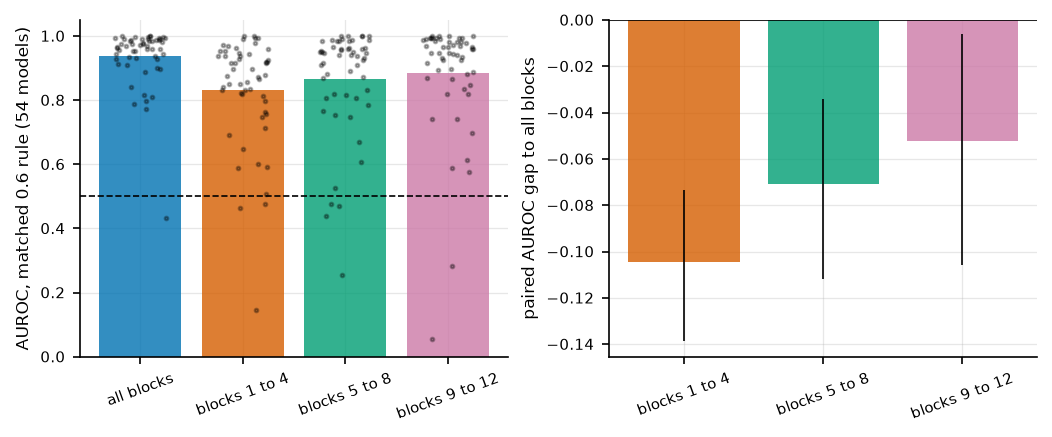

all blocks mean AUROC at the matched rule 0.938 over 54 models
standard deviation across models: {'all blocks': 0.092, 'blocks 1 to 4': 0.167, 'blocks 5 to 8': 0.167, 'blocks 9 to 12': 0.178}


In [5]:
per_model = token_frame[list(BANDS)].dropna()  # (models, bands)
figure, (mean_axis, gap_axis) = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 2.8), layout="constrained")
band_positions = np.arange(len(BANDS))  # (bands,)
band_colors = [OKABE_ITO[index] for index in range(len(BANDS))]
jitter = np.random.default_rng(0)

mean_axis.bar(band_positions, per_model.mean(), color=band_colors, alpha=0.8)
for position, band in zip(band_positions, BANDS):
    offsets = jitter.uniform(-0.25, 0.25, size=len(per_model))  # (models,)
    mean_axis.scatter(position + offsets, per_model[band], color="black", s=3, alpha=0.3)
mean_axis.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
mean_axis.set_xticks(band_positions, labels=list(BANDS), rotation=20)
mean_axis.set_ylabel(f"AUROC, matched {PLACEMENT_MATCH_TARGET} rule ({len(per_model)} models)")

gap_positions = band_positions[1:]  # (bands minus 1,)
gap_errors = np.vstack([token_gaps["gap to all blocks"] - token_gaps["low"], token_gaps["high"] - token_gaps["gap to all blocks"]])  # (2, bands minus 1)
gap_axis.bar(gap_positions, token_gaps["gap to all blocks"], color=band_colors[1:], alpha=0.8)
gap_axis.errorbar(gap_positions, token_gaps["gap to all blocks"], yerr=gap_errors, fmt="none", ecolor="black", linewidth=0.8)
gap_axis.axhline(0.0, color="black", linewidth=0.8)
gap_axis.set_xticks(gap_positions, labels=list(token_gaps.index), rotation=20)
gap_axis.set_ylabel("paired AUROC gap to all blocks")
plt.show()
print(f"all blocks mean AUROC at the matched rule {per_model['all blocks'].mean():.3f} over {len(per_model)} models")
print("standard deviation across models:", per_model.std().round(3).to_dict())
spread = per_model.std()  # (bands,)

In [6]:
display(Markdown(rf"""
{"Every band loses to all 12 blocks with its whole interval below 0" if (token_gaps["high"] < 0).all() else "Not every band loses to all 12 blocks with an interval below 0"}: {word_list([f"{b} by {g:+.3f}" for b, g in token_gaps["gap to all blocks"].items()])} (`\BandOneFourMinusAllInputSide`, `\BandFiveEightMinusAllInputSide`, `\BandNineOneTwoMinusAllInputSide`, each over {int(token_gaps["paired n"].min())} models). So no band of 4 blocks carries the signal on its own. At the panel level {token_gaps["gap to all blocks"].idxmax()} loses least and {token_gaps["gap to all blocks"].idxmin()} most. The spread across models is wider in every band (standard deviation {spread.drop("all blocks").min():.2f} to {spread.drop("all blocks").max():.2f}) than in all blocks ({spread["all blocks"]:.2f}), so a band that works on 1 model fails on another. The figure does not say which attacks drive the losses, the next figure.
"""))


Every band loses to all 12 blocks with its whole interval below 0: blocks 1 to 4 by -0.104, blocks 5 to 8 by -0.071 and blocks 9 to 12 by -0.052 (`\BandOneFourMinusAllInputSide`, `\BandFiveEightMinusAllInputSide`, `\BandNineOneTwoMinusAllInputSide`, each over 54 models). So no band of 4 blocks carries the signal on its own. At the panel level blocks 9 to 12 loses least and blocks 1 to 4 most. The spread across models is wider in every band (standard deviation 0.17 to 0.18) than in all blocks (0.09), so a band that works on 1 model fails on another. The figure does not say which attacks drive the losses, the next figure.


## Bands per attack

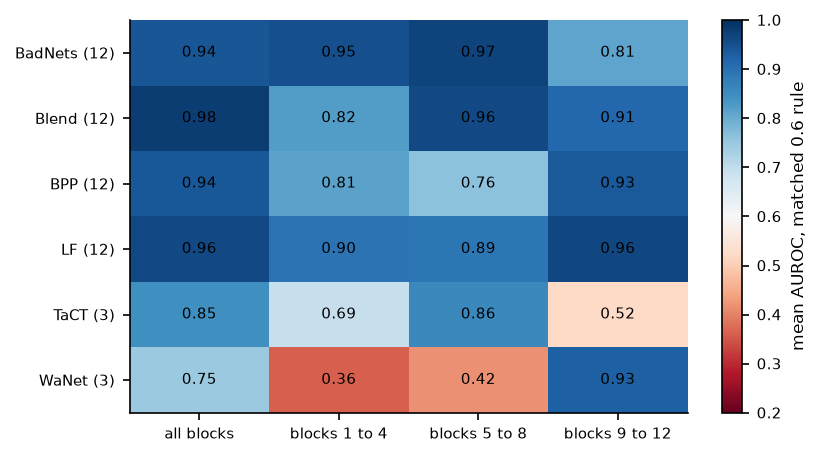

,all blocks,blocks 1 to 4,blocks 5 to 8,blocks 9 to 12
attack,,,,
badnet_a2o,0.943,0.952,0.971,0.811
blend,0.980,0.825,0.961,0.915
bpp,0.938,0.813,0.763,0.935
lf,0.961,0.897,0.888,0.964
tact,0.847,0.693,0.857,0.519
wanet,0.747,0.361,0.417,0.927


In [7]:
per_attack = per_model.join(token_frame["attack"]).groupby("attack").mean()  # (attacks, bands)
counts = per_model.join(token_frame["attack"]).groupby("attack").size()
figure, axis = plt.subplots(figsize=(6.0, 3.4))
image = axis.imshow(per_attack.to_numpy(), cmap="RdBu", vmin=0.2, vmax=1.0, aspect="auto")
for r in range(per_attack.shape[0]):
    for c in range(per_attack.shape[1]):
        axis.text(c, r, f"{per_attack.iat[r, c]:.2f}", ha="center", va="center", fontsize=7)
axis.set_xticks(range(per_attack.shape[1]), labels=per_attack.columns)
axis.set_yticks(range(per_attack.shape[0]), labels=[f"{attack_label(a)} ({counts[a]})" for a in per_attack.index])
axis.grid(False)
figure.colorbar(image, ax=axis, label=f"mean AUROC, matched {PLACEMENT_MATCH_TARGET} rule")
plt.show()
best_band = per_attack.drop(columns="all blocks").idxmax(axis=1)  # (attacks,)
beats_all = {attack_label(a): [b for b in list(BANDS)[1:] if per_attack.loc[a, b] > per_attack.loc[a, "all blocks"]] for a in per_attack.index}
beats_all = {a: b for a, b in beats_all.items() if b}
worst_band = per_attack.drop(columns="all blocks").idxmin(axis=1)  # (attacks,)
per_attack.round(3)

In [8]:
display(Markdown(rf"""
The best band differs from attack to attack: {word_list([f"{b} on {attack_label(a)}" for a, b in best_band.items()])}. A band beats all 12 blocks on {word_list([f"{a} ({word_list(b)})" for a, b in beats_all.items()])}, and the worst band per attack is {word_list([f"{b} on {attack_label(a)} ({per_attack.loc[a, b]:.3f})" for a, b in worst_band.items()])}, so no single band is safe on every attack. The BadNets late-band reading is at odds with a naive reading of the late trigger read, and 1 reading consistent with part B of `mechanism.ipynb` is that the late band needs a high rate to reach the matched shift, at which every trigger token is hidden in all 4 late blocks often enough to break triggered predictions too. That reading was not tested here. The rows with few models ({word_list([f"{attack_label(a)} {n}" for a, n in counts.items() if n < 10])}) are noisy. The heatmap does not compare with residual dropout, the last section.
"""))


The best band differs from attack to attack: blocks 5 to 8 on BadNets, blocks 5 to 8 on Blend, blocks 9 to 12 on BPP, blocks 9 to 12 on LF, blocks 5 to 8 on TaCT and blocks 9 to 12 on WaNet. A band beats all 12 blocks on BadNets (blocks 1 to 4 and blocks 5 to 8), LF (blocks 9 to 12), TaCT (blocks 5 to 8) and WaNet (blocks 9 to 12), and the worst band per attack is blocks 9 to 12 on BadNets (0.811), blocks 1 to 4 on Blend (0.825), blocks 5 to 8 on BPP (0.763), blocks 5 to 8 on LF (0.888), blocks 9 to 12 on TaCT (0.519) and blocks 1 to 4 on WaNet (0.361), so no single band is safe on every attack. The BadNets late-band reading is at odds with a naive reading of the late trigger read, and 1 reading consistent with part B of `mechanism.ipynb` is that the late band needs a high rate to reach the matched shift, at which every trigger token is hidden in all 4 late blocks often enough to break triggered predictions too. That reading was not tested here. The rows with few models (TaCT 3 and WaNet 3) are noisy. The heatmap does not compare with residual dropout, the last section.


## The same bands for residual dropout

For dropout before both adds, `pre_residual`, the bands behave differently. The gaps below are against `pre_residual` in all 12 blocks, checked against the `BandXMinusAllResidual` macros.

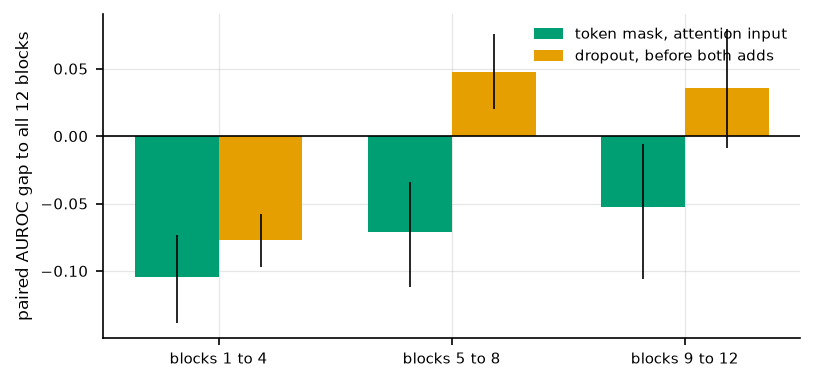

,paired n,mean band AUROC,gap to all blocks,low,high
band,,,,,
blocks 1 to 4,54,0.786,-0.077,-0.097,-0.057
blocks 5 to 8,54,0.911,0.048,0.021,0.076
blocks 9 to 12,54,0.899,0.036,-0.009,0.080


In [9]:
figure, axis = plt.subplots(figsize=(6.0, 2.8))
positions = np.arange(len(token_gaps))  # (bands minus 1,)
for offset, (label, gaps, color) in enumerate((("token mask, attention input", token_gaps, OKABE_ITO[2]), ("dropout, before both adds", residual_gaps, OKABE_ITO[4]))):
    errors = np.vstack([gaps["gap to all blocks"] - gaps["low"], gaps["high"] - gaps["gap to all blocks"]])  # (2, bands minus 1)
    axis.bar(positions + (offset - 0.5) * 0.36, gaps["gap to all blocks"], width=0.36, color=color, label=label)
    axis.errorbar(positions + (offset - 0.5) * 0.36, gaps["gap to all blocks"], yerr=errors, fmt="none", ecolor="black", lw=0.8)
axis.axhline(0, color="black", lw=0.8)
axis.set_xticks(positions, labels=list(token_gaps.index))
axis.set_ylabel("paired AUROC gap to all 12 blocks")
axis.legend()
plt.show()
residual_gaps.round(3)

In [10]:
display(Markdown(rf"""
Residual dropout behaves differently, with the middle and late bands at or above all 12 blocks: {word_list([f"{b} {g:+.3f} [{l:+.3f}, {h:+.3f}]" for b, g, l, h in zip(residual_gaps.index, residual_gaps["gap to all blocks"], residual_gaps["low"], residual_gaps["high"])])} against `pre_residual` in all 12 blocks. The best residual placement of the basis is `\BestResidualName`, "{macro("best_residual", "BestResidualName")}". A reading consistent with part C of `mechanism.ipynb` is that dropout on the stream corrupts trigger and clean content alike wherever it acts, so confining it to the middle blocks spends the disturbance where the class decision is formed, but no experiment here isolates that. Token masking loses in every band, since each block's mask is drawn afresh and only the union over all blocks hides a trigger reliably. Even the best residual placement trails PSBD-TM on the headline panel by {macro("best_residual", "BestResidualGain")} [{macro("best_residual", "BestResidualGainLow").replace("$-$", "−")}, {macro("best_residual", "BestResidualGainHigh")}] at the adaptive rule (`\BestResidualGain`). The figure is at the matched rule, and the adaptive-rule reading of the same bands is the staircase in `placement-walk.ipynb`.
"""))


Residual dropout behaves differently, with the middle and late bands at or above all 12 blocks: blocks 1 to 4 -0.077 [-0.097, -0.057], blocks 5 to 8 +0.048 [+0.021, +0.076] and blocks 9 to 12 +0.036 [-0.009, +0.080] against `pre_residual` in all 12 blocks. The best residual placement of the basis is `\BestResidualName`, "dropout, before both residual adds, blocks 5 to 8". A reading consistent with part C of `mechanism.ipynb` is that dropout on the stream corrupts trigger and clean content alike wherever it acts, so confining it to the middle blocks spends the disturbance where the class decision is formed, but no experiment here isolates that. Token masking loses in every band, since each block's mask is drawn afresh and only the union over all blocks hides a trigger reliably. Even the best residual placement trails PSBD-TM on the headline panel by +0.048 [+0.008, +0.092] at the adaptive rule (`\BestResidualGain`). The figure is at the matched rule, and the adaptive-rule reading of the same bands is the staircase in `placement-walk.ipynb`.
